In [3]:
import numpy as np
import sep

In [4]:
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

In [5]:
filename = 'hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits'
data = fits.getdata(filename)

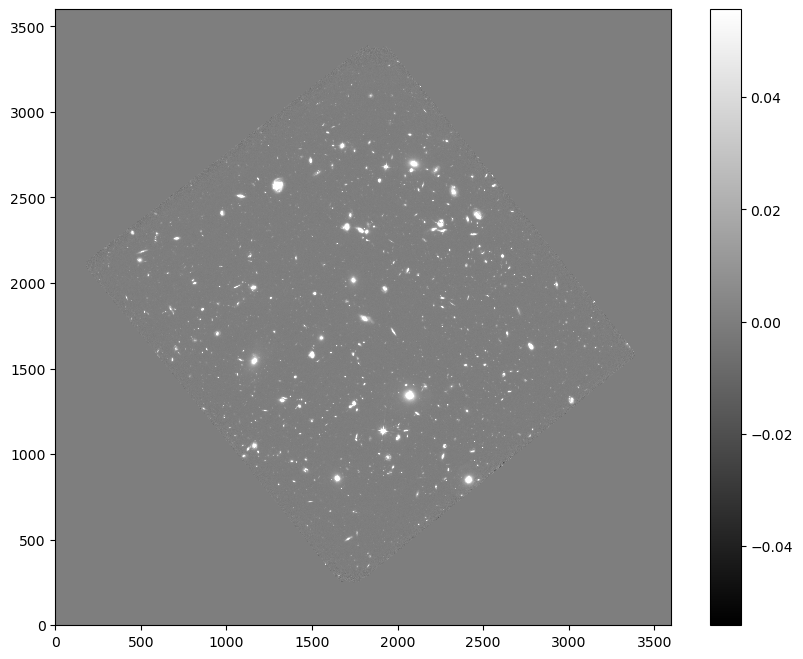

In [6]:
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar();

In [7]:
data = data.byteswap()
data = data.view(data.dtype.newbyteorder("="))
bkg = sep.Background(data, bw=64, bh=64, fw=3, fh=3)

In [8]:
print(bkg.globalback)
print(bkg.globalrms)

0.0
0.0005398219218477607


In [9]:
bkg_image = bkg.back()

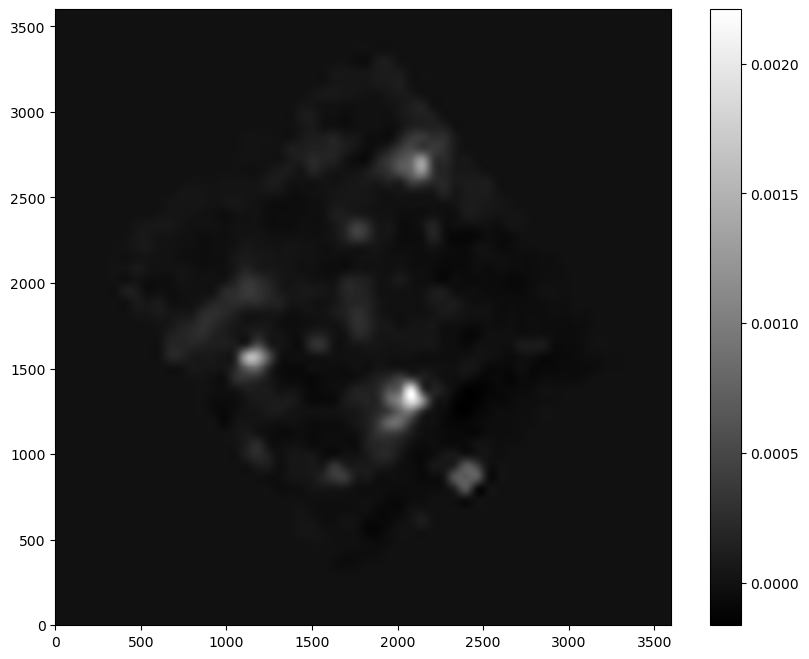

In [10]:
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [11]:
bkg_rms = bkg.rms()

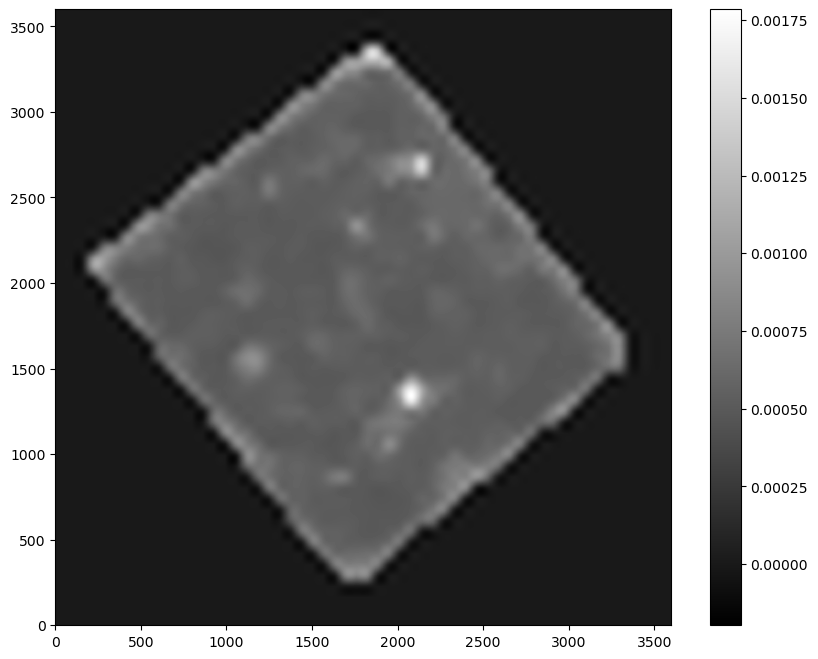

In [12]:
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [13]:
data_sub = data - bkg

In [14]:
objects = sep.extract(data_sub, 1.5, err=bkg.globalrms)

In [15]:
len(objects)

8640

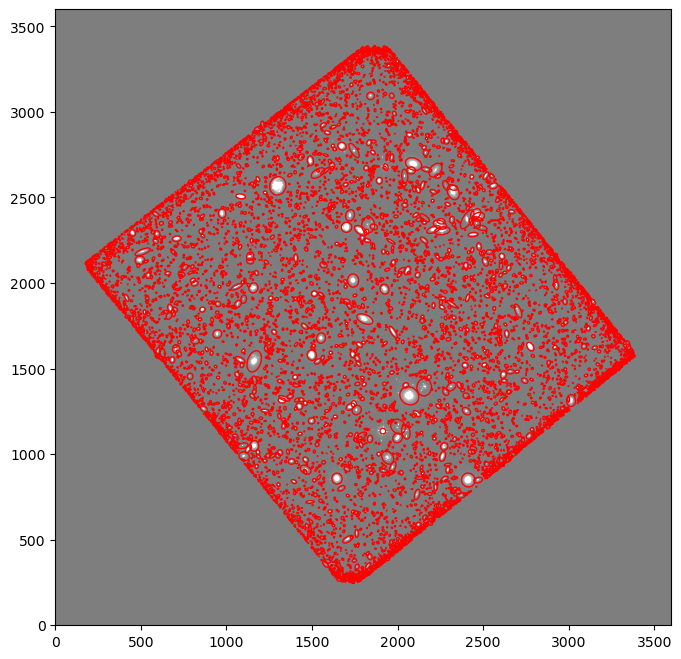

In [16]:
from matplotlib.patches import Ellipse

fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

In [17]:
objects.dtype.names

('thresh',
 'npix',
 'tnpix',
 'xmin',
 'xmax',
 'ymin',
 'ymax',
 'x',
 'y',
 'x2',
 'y2',
 'xy',
 'errx2',
 'erry2',
 'errxy',
 'a',
 'b',
 'theta',
 'cxx',
 'cyy',
 'cxy',
 'cflux',
 'flux',
 'cpeak',
 'peak',
 'xcpeak',
 'ycpeak',
 'xpeak',
 'ypeak',
 'flag')

In [18]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err=bkg.globalrms, gain=1.0)

In [19]:
for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 0.031282 +/- 0.176890
object 1: flux = 0.031018 +/- 0.176142
object 2: flux = -0.024388 +/- 0.002883
object 3: flux = 0.001947 +/- 0.044219
object 4: flux = 0.012457 +/- 0.111649
object 5: flux = -0.011228 +/- 0.002875
object 6: flux = 0.029368 +/- 0.171394
object 7: flux = -0.009126 +/- 0.002875
object 8: flux = 0.048023 +/- 0.219161
object 9: flux = 0.027840 +/- 0.166877


IndexError: tuple index out of range

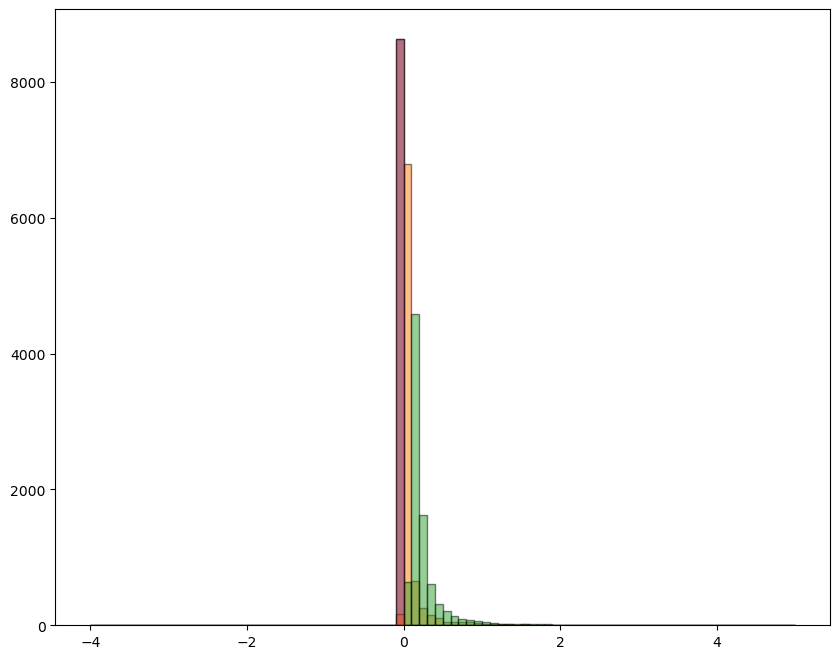

In [43]:
# 1) 8640 stars
b =len(objects)
for i in range(b):
    flux_val= flux[i-1]
    plt.hist(flux[i-1],bins=bins,alpha=0.5,edgecolor = 'black')

plt.show

In [29]:
# 2)
print(np.mean(data))
print(np.std(data))
print(np.median(data))

0.0007912985
0.054868467
0.0


In [48]:
# 3)
from scipy import stats
z_scores = stats.zscore(data)
largest_outlier_index = np.argmax(np.abs(z_scores))
largest_outlier_value = data[largest_outlier_index]
deviations_from_mean = np.abs(z_scores[largest_outlier_index])

print(f"Mean of the data: {np.mean(data):.2f}")
print(f"Standard deviation of the data: {np.std(data):.2f}")
print(f"Largest Outlier Value: {largest_outlier_value}")

Mean of the data: 0.00
Standard deviation of the data: 0.05
Largest Outlier Value: [0. 0. 0. ... 0. 0. 0.]
